In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.geoaxes import GeoAxes
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [3]:
from xmip.preprocessing import combined_preprocessing
import regionmask
from xmip.regionmask import merged_mask
import warnings
import matplotlib.pyplot as plt
import numpy as np
import glob
import xarray as xr
import xbudget
import regionate
import xwmt
import xwmb
import xgcm
import matplotlib.colors as mcolors
import cmocean
import cartopy.crs as ccrs
from scipy.interpolate import PchipInterpolator
# import CM4Xutils #needed to run pip install nc-time-axis
# from regionate import MaskRegions, GriddedRegion
import sys
sys.path.insert(0, '/user/anthony.meza/CM4XAbyssalSWMT/src')
from src import *
import matplotlib as mpl
import seaborn as sns
sns.set_theme(context='notebook', style='ticks')
mpl.rcParams['figure.dpi'] = 150

### Request HPC Resources

In [4]:
from dask_jobqueue import SLURMCluster  # setup dask cluster 
from dask.distributed import Client

log_directory="/user/anthony.meza/CM4XAbyssalSWMT/notebooks/logs"

cluster = SLURMCluster(
    cores=36,
    processes=1,
    memory='190GB',
    walltime='03:00:00',
    queue='scavenger',
log_directory = log_directory)
print(cluster.job_script())
cluster.scale(jobs=16)

client = Client(cluster)
client

#!/usr/bin/env bash

#SBATCH -J dask-worker
#SBATCH -e /user/anthony.meza/CM4XAbyssalSWMT/notebooks/logs/dask-worker-%J.err
#SBATCH -o /user/anthony.meza/CM4XAbyssalSWMT/notebooks/logs/dask-worker-%J.out
#SBATCH -p scavenger
#SBATCH -n 1
#SBATCH --cpus-per-task=36
#SBATCH --mem=177G
#SBATCH -t 03:00:00

/user/anthony.meza/miniforge3/envs/cm4x_chapter2/bin/python -m distributed.cli.dask_worker tcp://10.151.1.137:33431 --name dummy-name --nthreads 36 --memory-limit 176.95GiB --nanny --death-timeout 60



Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://10.151.1.137:33431,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [5]:
native_path = datadir("transient_tracers_z")
files = ["CM4Xp125_piControl_transient_tracers_z.zarr", "CM4Xp125_historical_transient_tracers_z.zarr", "CM4Xp125_ssp585_transient_tracers_z.zarr"]
full_depth_files = [native_path + "/" + a for a in files]

files = ["CM4Xp125_piControl_transient_tracers_surface.zarr", 
         "CM4Xp125_historical_transient_tracers_surface.zarr", 
         "CM4Xp125_ssp585_transient_tracers_surface.zarr"]
surface_files = [native_path + "/" + a for a in files]

In [6]:
def preprocess(ds):
    if ("year_ctrl" in ds.coords) or ("time_ctrl" in ds.coords):
        # if "time_ctrl" in ds.coords:
        #     ds = ds.reset_coords("year_ctrl", drop=True)
        # else:
        #     ds = ds.reset_coords("time_ctrl", drop=True)
        ds = ds.expand_dims(expt=["control"])
        ds.coords["year"] = ds.coords["year"]
        ds = ds.drop_vars(["year_ctrl"])
    else: 
        ds = ds.expand_dims(expt=["forced"])        
    return ds.isel(yh = slice(0, 150)).sel(year = slice(None, 2099))
ds_ctrl= xr.open_mfdataset(full_depth_files[0], combine="nested", concat_dim=["year"], parallel=True, preprocess=preprocess, engine = "zarr")
ds_forced = xr.open_mfdataset(full_depth_files[1:], combine="nested", concat_dim=["year"], parallel=True, preprocess=preprocess, engine = "zarr")

ds= xr.concat([ds_ctrl, ds_forced], dim = "expt")

In [7]:
z_i = np.array([0.000e+00, 5.000e+00, 1.500e+01, 2.500e+01, 4.000e+01, 6.250e+01,
       8.750e+01, 1.125e+02, 1.375e+02, 1.750e+02, 2.250e+02, 2.750e+02,
       3.500e+02, 4.500e+02, 5.500e+02, 6.500e+02, 7.500e+02, 8.500e+02,
       9.500e+02, 1.050e+03, 1.150e+03, 1.250e+03, 1.350e+03, 1.450e+03,
       1.625e+03, 1.875e+03, 2.250e+03, 2.750e+03, 3.250e+03, 3.750e+03,
       4.250e+03, 4.750e+03, 5.250e+03, 5.750e+03, 6.250e+03, 6.750e+03])
ds = ds.assign_coords({"z_i":z_i})

In [8]:
import CM4Xutils, regionate
def generate_isobath_mask(ds, isobath):
    ds = ds.fillna(0.0)

    ds['mask'] = (
        (ds['geolat'] <= -50.0) * 
    (ds["deptho"].fillna(0.0) <= isobath))
    
    grid = CM4Xutils.ds_to_grid(ds)
    regions = regionate.MaskRegions(ds.mask, grid).region_dict
    antarctic = regions[0] #there are more in this list if there are multiple contours 
    region = regionate.GriddedRegion("antarctic", antarctic.lons_c, antarctic.lats_c, grid, 
                           ij=(antarctic.i_c, antarctic.j_c))
    return region

In [60]:
mask_dict = dict()
for isobath in [0.0, 500.0, 1000.0, 2500.0]:
    mask_dict[isobath] = generate_isobath_mask(ds, isobath)

Inferring Z grid coordinate: depth `z_`
Inferring Z grid coordinate: depth `z_`
Inferring Z grid coordinate: depth `z_`
Inferring Z grid coordinate: depth `z_`


In [62]:
import scipy.ndimage as ndi

mask_dict_boundary = dict()
for isobath in mask_dict.keys():
    x = mask_dict[isobath]
    mask_dict_boundary[isobath] = x.mask & ~ndi.binary_erosion(x.mask, mask = x.mask.values, border_value = True)
    mask_dict_boundary[isobath] = mask_dict_boundary[isobath].where(mask_dict_boundary[isobath] > 0.0)

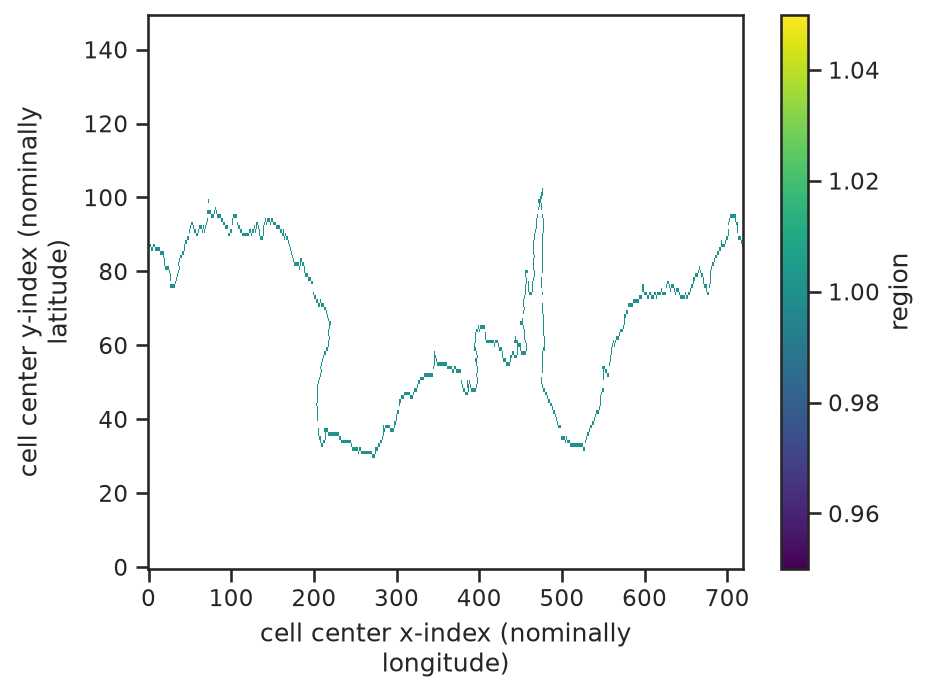

In [64]:
(mask_dict_boundary[0]).plot()

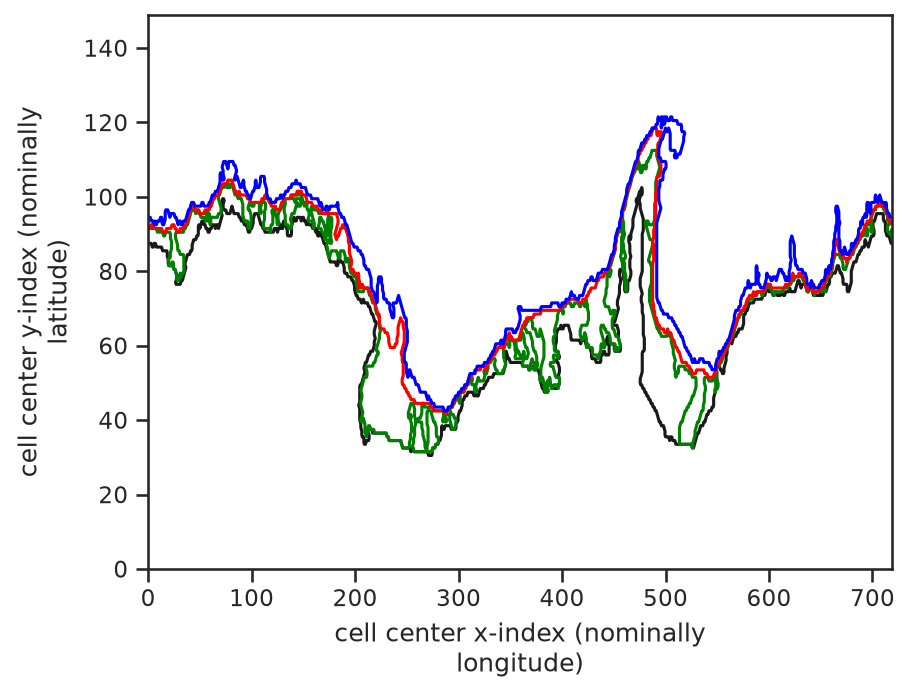

In [35]:
mask_dict[0].plot.contour(colors = "k")
mask_dict[500.0].plot.contour(colors = "green")
mask_dict[1000.0].plot.contour(colors = "red")
mask_dict[2500.0].plot.contour(colors = "blue")

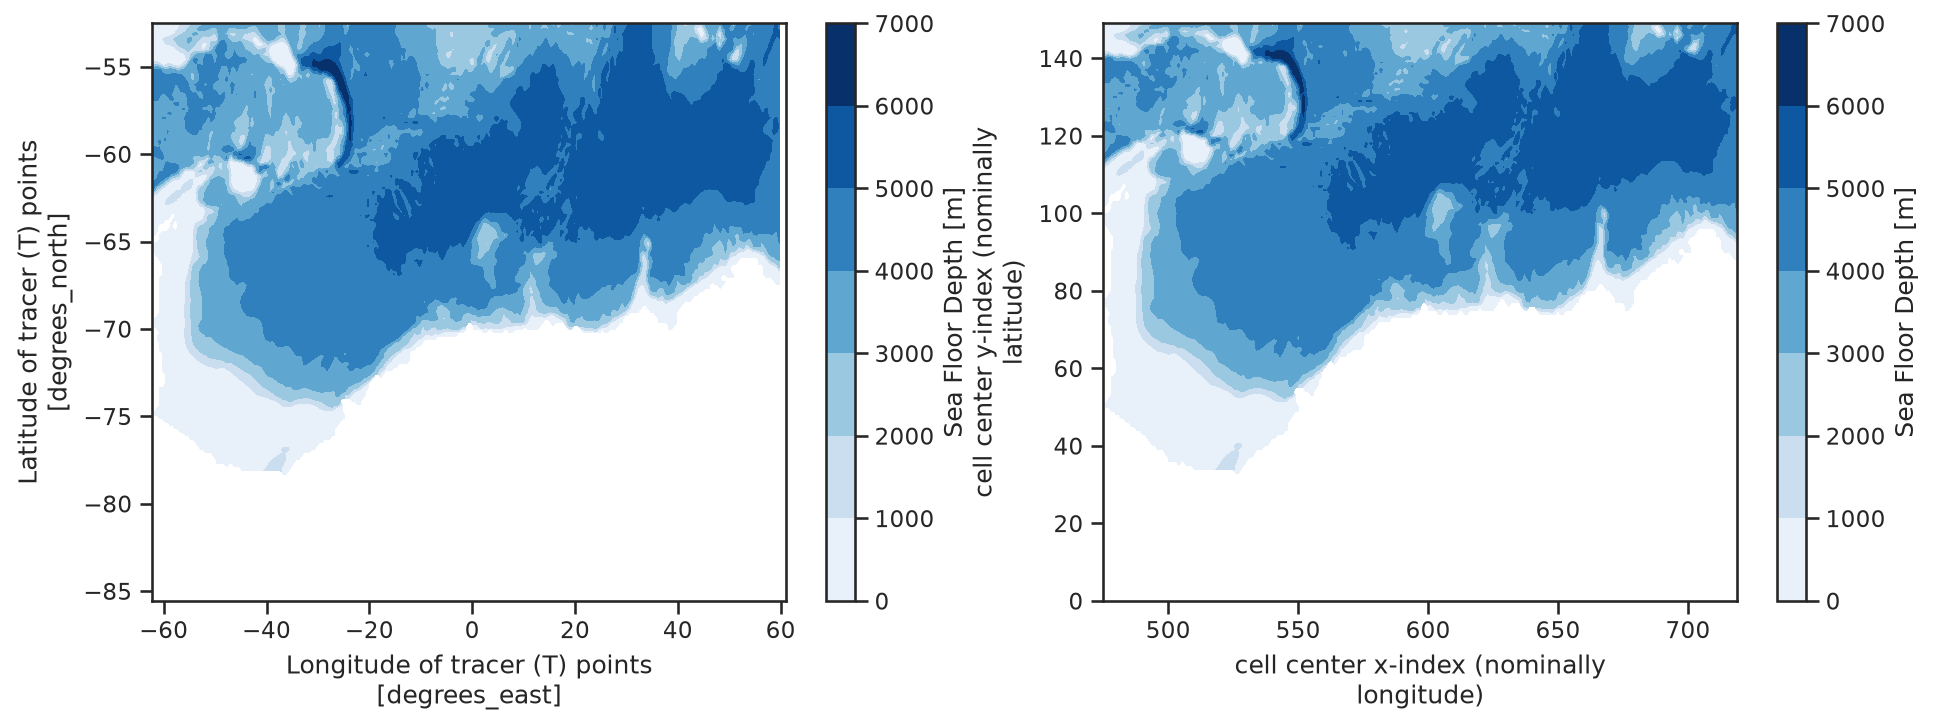

In [9]:
fig, ax = plt.subplots(1,2, figsize = (15, 5))
ds_subset = ds.isel(xh = slice(475, 1000))
ds_subset.deptho.plot.contourf(ax = ax[0], x = "geolon", y = "geolat", cmap = "Blues")
ds_subset.deptho.plot.contourf(ax = ax[1], cmap = "Blues")

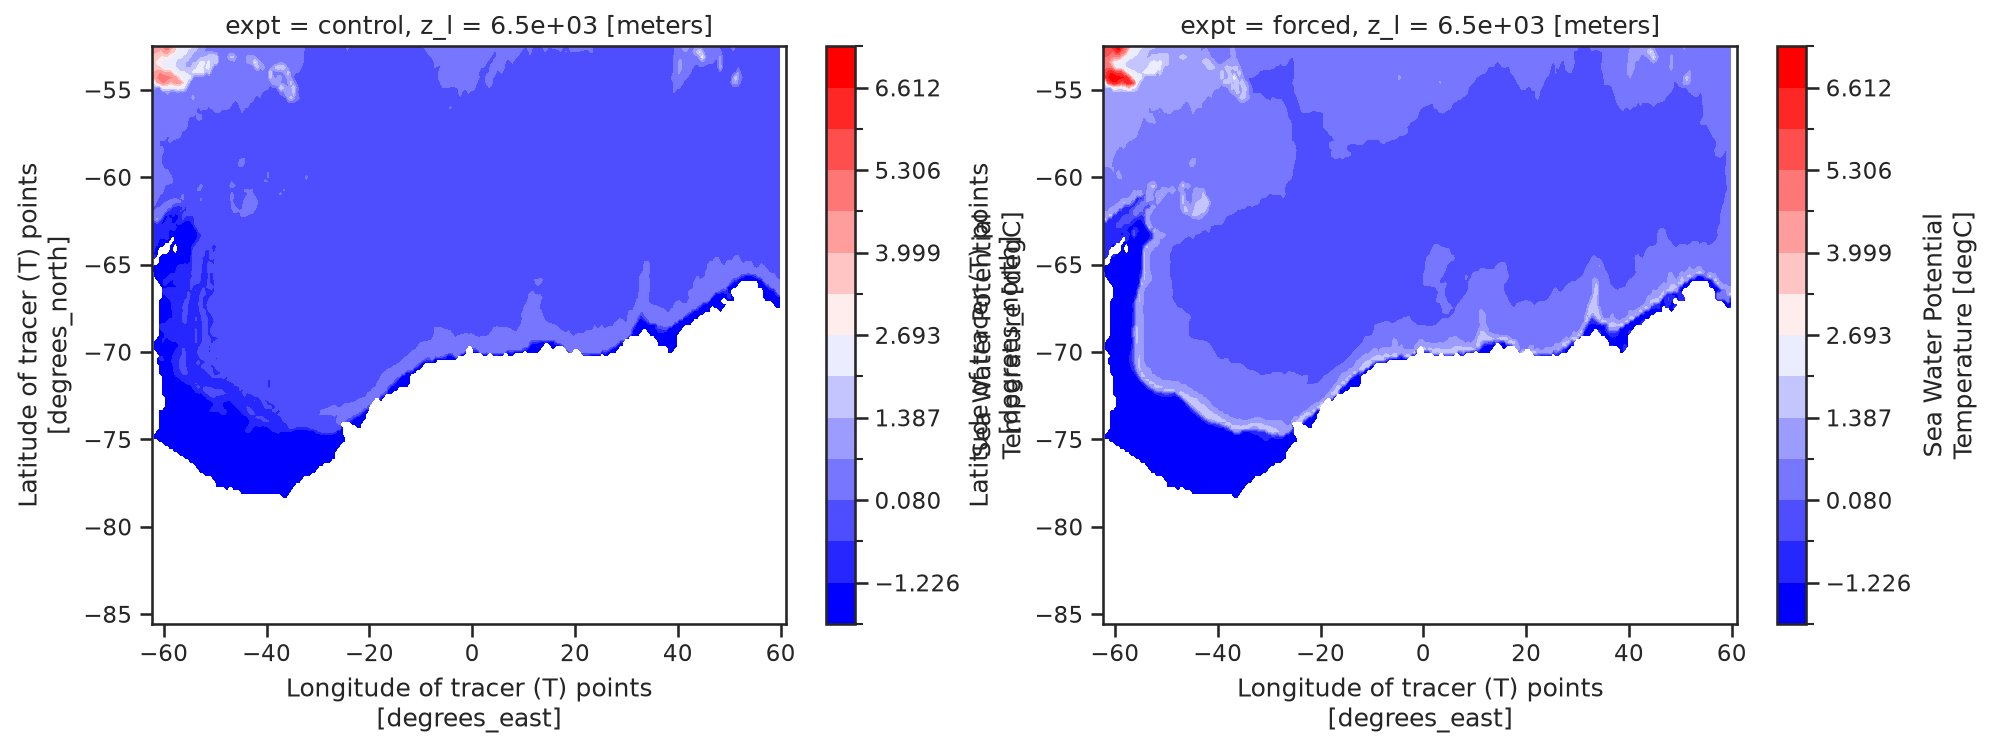

In [10]:
fig, ax = plt.subplots(1,2, figsize = (15, 5))
ds_subset = ds.isel(xh = slice(475, None)).isel(year = slice(-50, None)).mean("year").ffill("z_l")
ds_subset = ds_subset.thetao.isel(z_l = -1)
vmin = ds_subset.min().compute().values
vmax = ds_subset.max().compute().values

levels = np.linspace(vmin, vmax, 15)
ds_subset.isel(expt = 0).plot.contourf(ax = ax[0], x = "geolon", y = "geolat", 
                                       vmin = vmin, vmax = vmax, levels = levels, 
                                      cmap = "bwr")
ds_subset.isel(expt = 1).plot.contourf(ax = ax[1], x = "geolon", y = "geolat", 
                                       vmin = vmin, vmax = vmax, levels = levels, 
                                      cmap = "bwr")

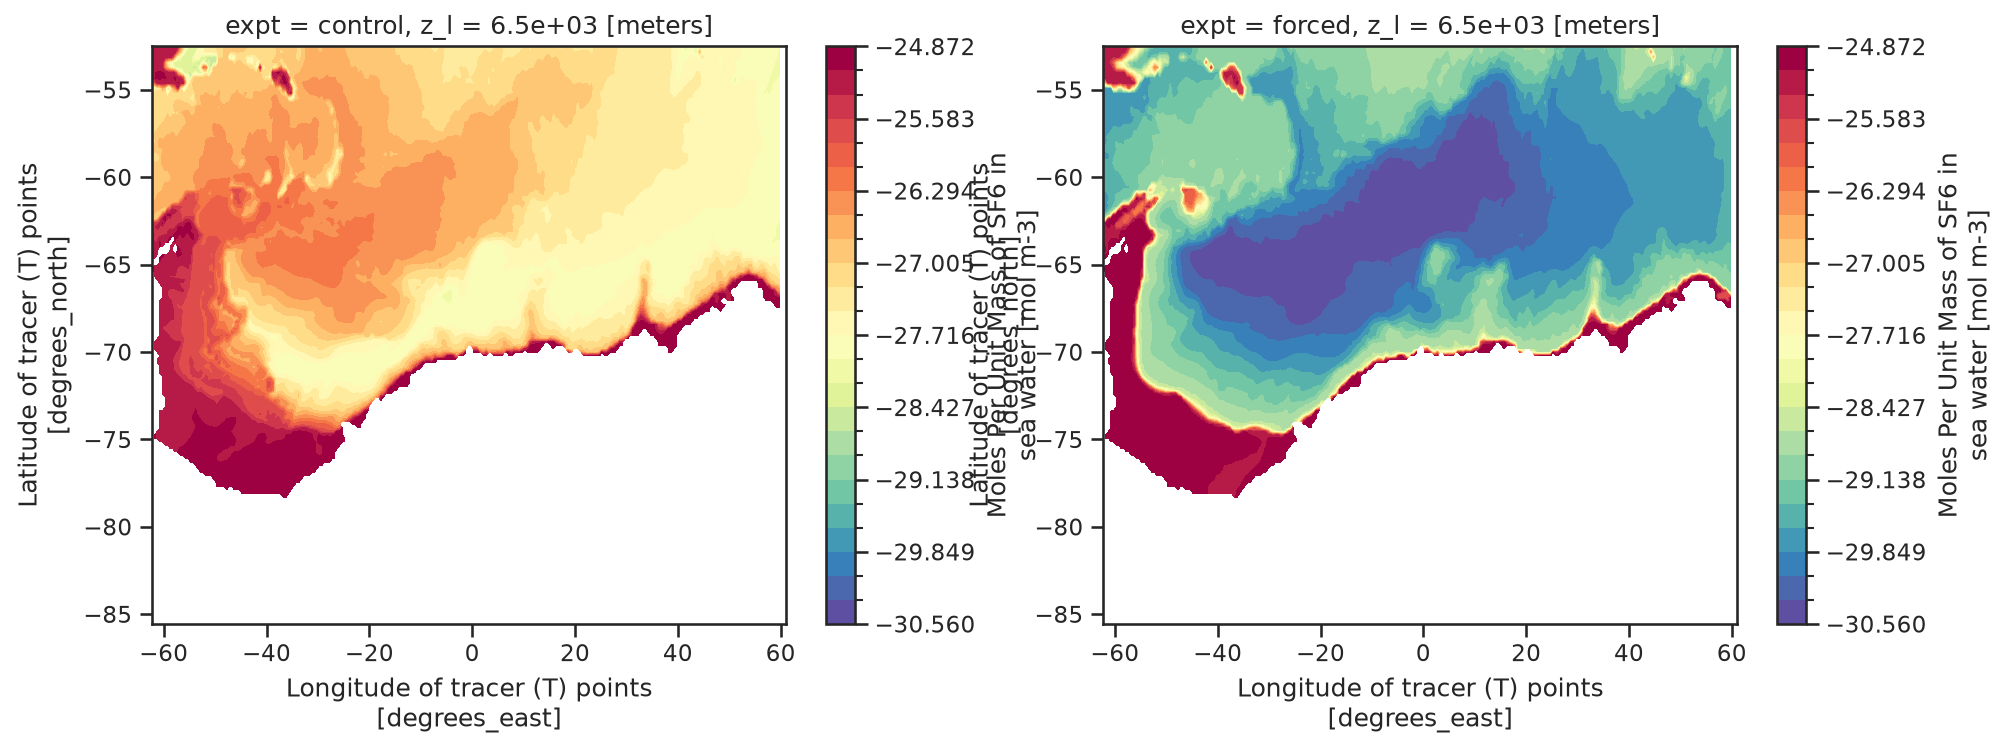

In [11]:
fig, ax = plt.subplots(1,2, figsize = (15, 5))
ds_subset = ds.isel(xh = slice(475, None)).isel(year = slice(-25, None)).mean("year").ffill("z_l")
ds_subset = np.log(ds_subset.sf6.isel(z_l = -1))
vmin = ds_subset.min().compute().values
vmax = ds_subset.max().compute().values

levels = np.linspace(vmin, vmax, 25)
ds_subset.isel(expt = 0).plot.contourf(ax = ax[0], x = "geolon", y = "geolat", 
                                       vmin = vmin, vmax = vmax, levels = levels, 
                                      cmap = "Spectral_r")
ds_subset.isel(expt = 1).plot.contourf(ax = ax[1], x = "geolon", y = "geolat", 
                                       vmin = vmin, vmax = vmax, levels = levels, 
                                      cmap = "Spectral_r")

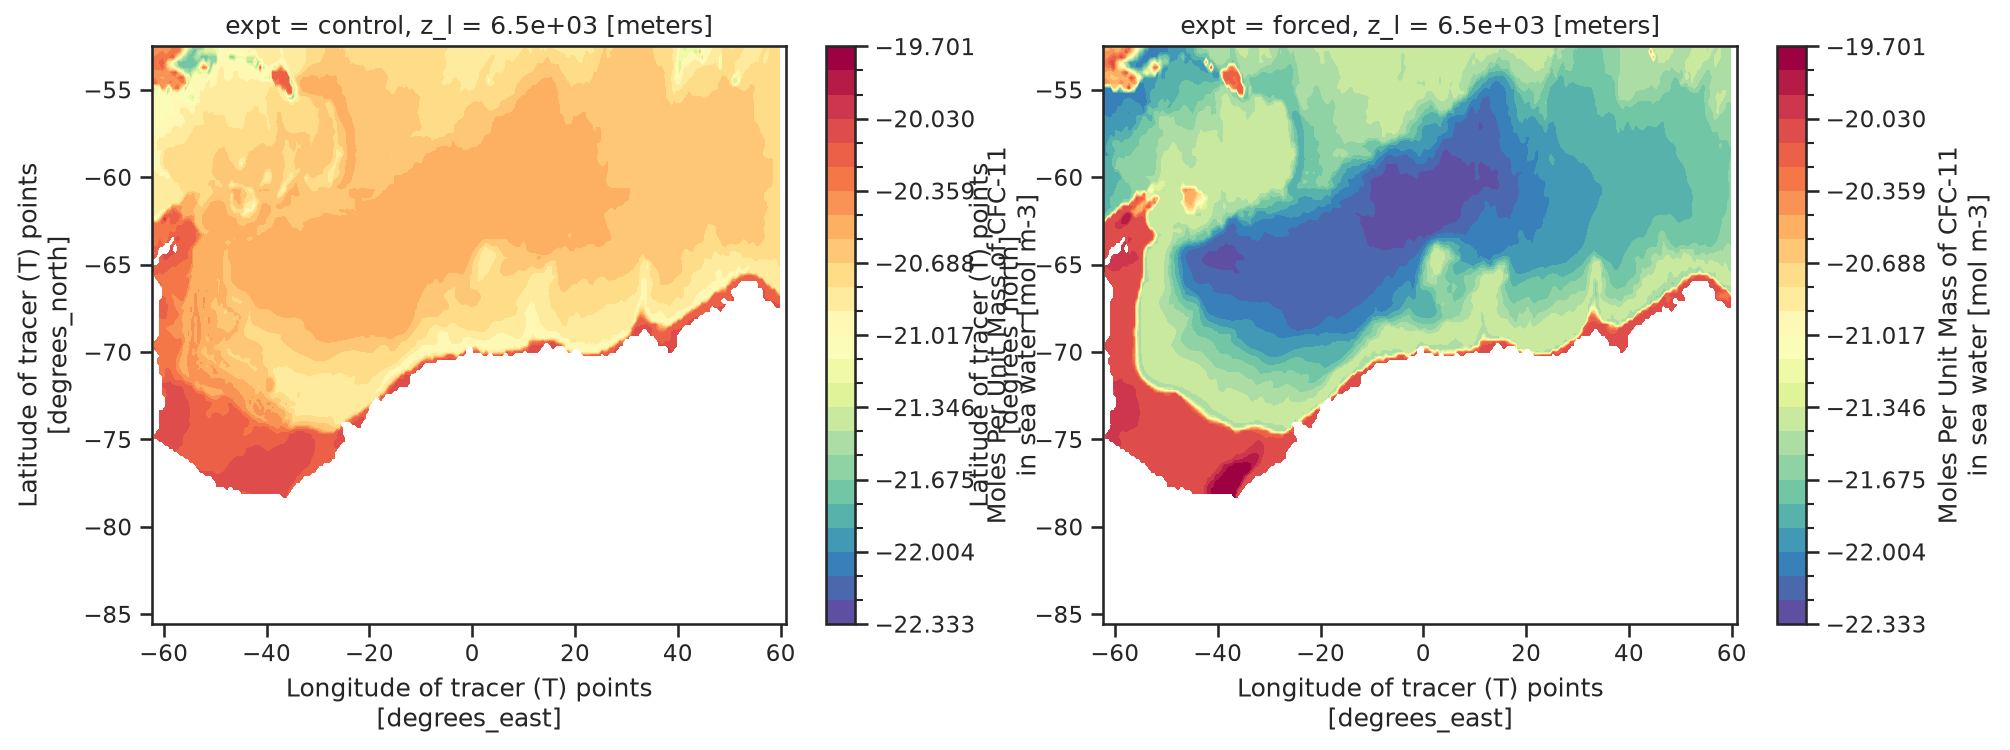

In [12]:
fig, ax = plt.subplots(1,2, figsize = (15, 5))
ds_subset = ds.isel(xh = slice(475, None)).isel(year = slice(-25, None)).mean("year").ffill("z_l")
ds_subset = np.log(ds_subset.cfc11.isel(z_l = -1))
vmin = ds_subset.min().compute().values
vmax = ds_subset.max().compute().values

levels = np.linspace(vmin, vmax, 25)
ds_subset.isel(expt = 0).plot.contourf(ax = ax[0], x = "geolon", y = "geolat", 
                                       vmin = vmin, vmax = vmax, levels = levels, 
                                      cmap = "Spectral_r")
ds_subset.isel(expt = 1).plot.contourf(ax = ax[1], x = "geolon", y = "geolat", 
                                       vmin = vmin, vmax = vmax, levels = levels, 
                                      cmap = "Spectral_r")

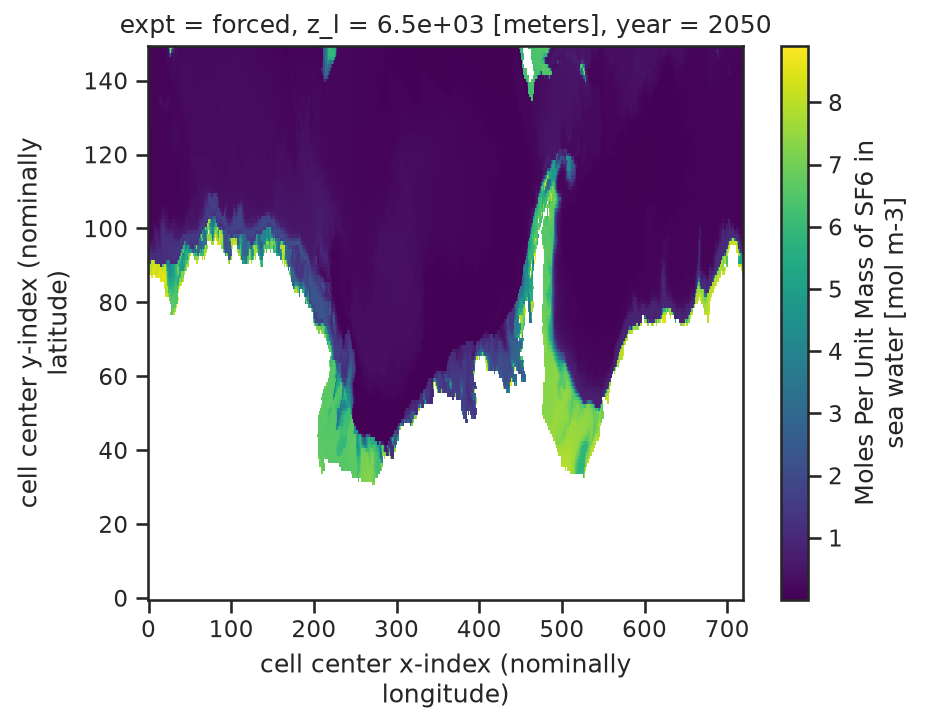

In [13]:
bottom_sf6 = ds["sf6"].ffill("z_l").isel(z_l = -1).compute()

bottom_sf6 = bottom_sf6 * 1e12 / 1035 * 1e3
bottom_sf6.isel(expt = 1).sel(year = 2050).plot()

In [14]:
rename_geocoords = lambda ds: ds.rename({"lat":"old_lat", "lon":"old_lon"}).rename({"geolat":"lat", "geolon":"lon"})
ds_weddell = rename_geocoords(ds)
ds_weddell = ds_weddell.reset_coords(names='deptho')
ds_weddell = ds_weddell.isel(xh = slice(475, 600))
ds_weddell_zstar = 1 * ds_weddell

In [15]:
rename_geocoords = lambda ds: ds.rename({"lat":"old_lat", "lon":"old_lon"}).rename({"geolat":"lat", "geolon":"lon"})
grid = Grid(ds, coords={"Z": {"center": "z_l"}}, periodic=False, autoparse_metadata=False)

ds_filtered = ds.where(ds.thkcello.fillna(0.0) > 0.0)
ds_filtered["depth"] = approximate_z_top_down(ds, dim="z")
ds_filtered = ds_filtered.chunk({"z_l":-1})
depth_target = np.arange(-7000.0, 0.1, 50)

data_vars = [v for v in ds_filtered.data_vars if v not in ["thkcello", "depth", "volcello"]]
ds_remap = xr.merge([grid.transform(ds_filtered[var], "Z", depth_target, target_data=ds_filtered["depth"]) for var in data_vars])
ds_weddell = rename_geocoords(ds_remap).rename({"depth":"z_l"})
ds_weddell = ds_weddell.reset_coords(names='deptho')
ds_weddell = ds_weddell.isel(xh = slice(475, 600))

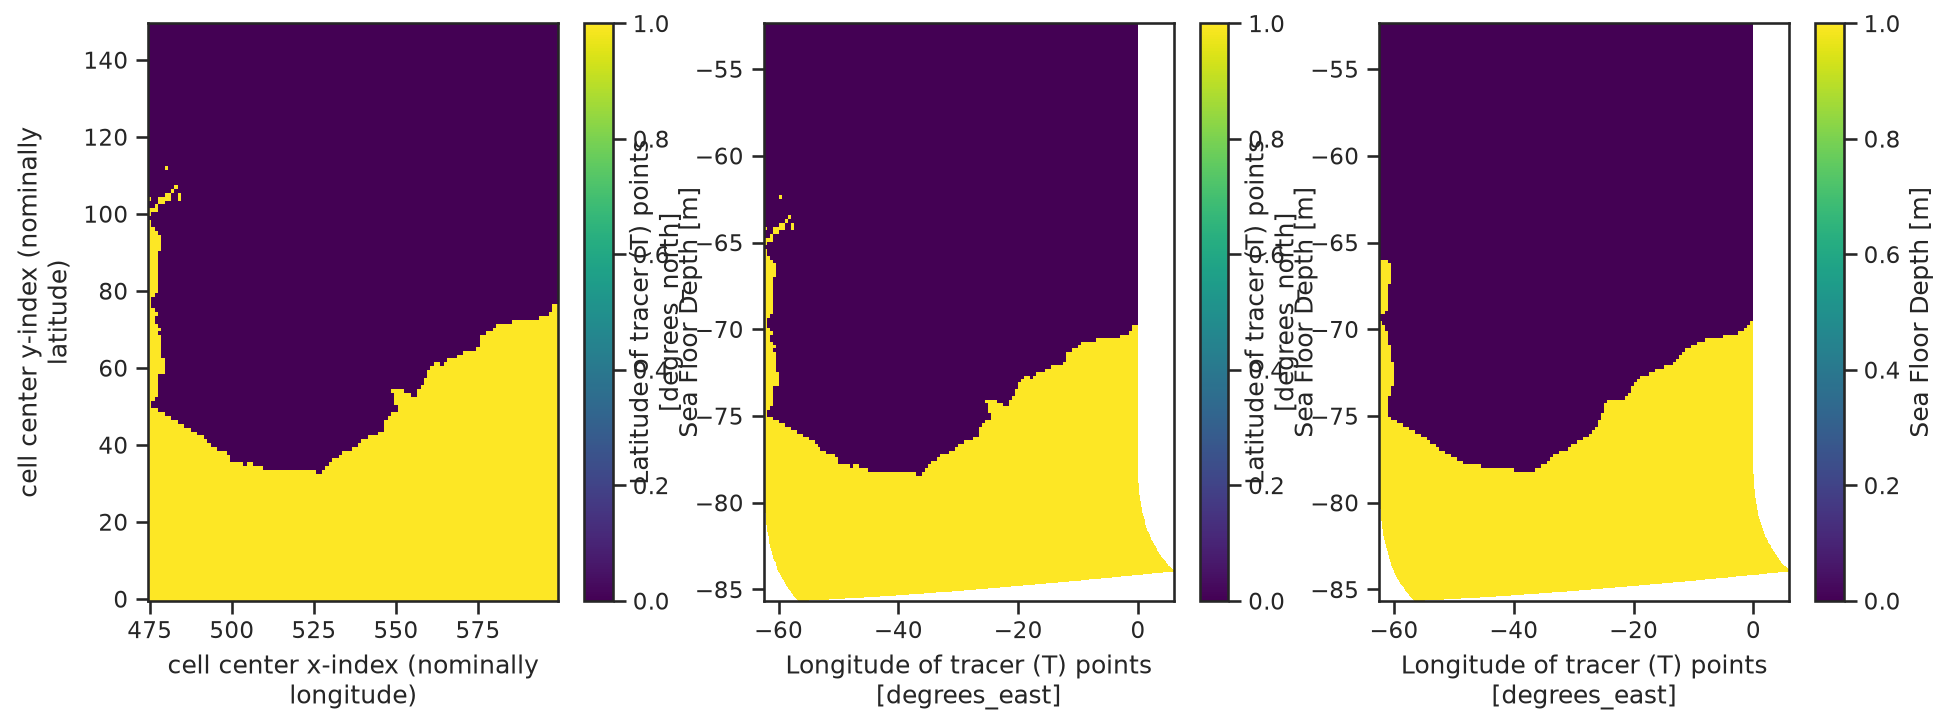

In [16]:
fig, ax = plt.subplots(1,3, figsize = (15, 5))
boundary_mask = (ds_weddell.deptho.fillna(0.0) <= 50.0).compute()
boundary_mask.plot(ax = ax[0])
boundary_mask.plot(ax = ax[1], x = "lon", y = "lat")

from scipy.ndimage import gaussian_filter

mask_smooth_binary = 1 * boundary_mask
mask_smooth_binary.values = gaussian_filter(
    mask_smooth_binary.astype(float),
    sigma=(2, 2),
    mode=("nearest", "wrap"),
) > 0.4

mask_smooth_binary.plot(ax = ax[2], x = "lon", y = "lat")


In [17]:
transects, geometry = xshelftransects.cross_shelf_transects(
    ds_weddell,
    ["thetao", "cfc11", "sf6", "so", "sigma2_offline", "sigma2"],                    # str | list[str]
    mask_smooth_binary,          # DataArray; contour(level=0.5) defines transect_length=0
    transect_length=np.arange(0.0, 16 * 100e3 + 2e3, 5.0e3),
    transect_spacing=40e3,
    crs="EPSG:3031",
    engine="xesmf",
    method="bilinear",
    lon_name="lon",
    lat_name="lat",
    return_geometry=True,
)

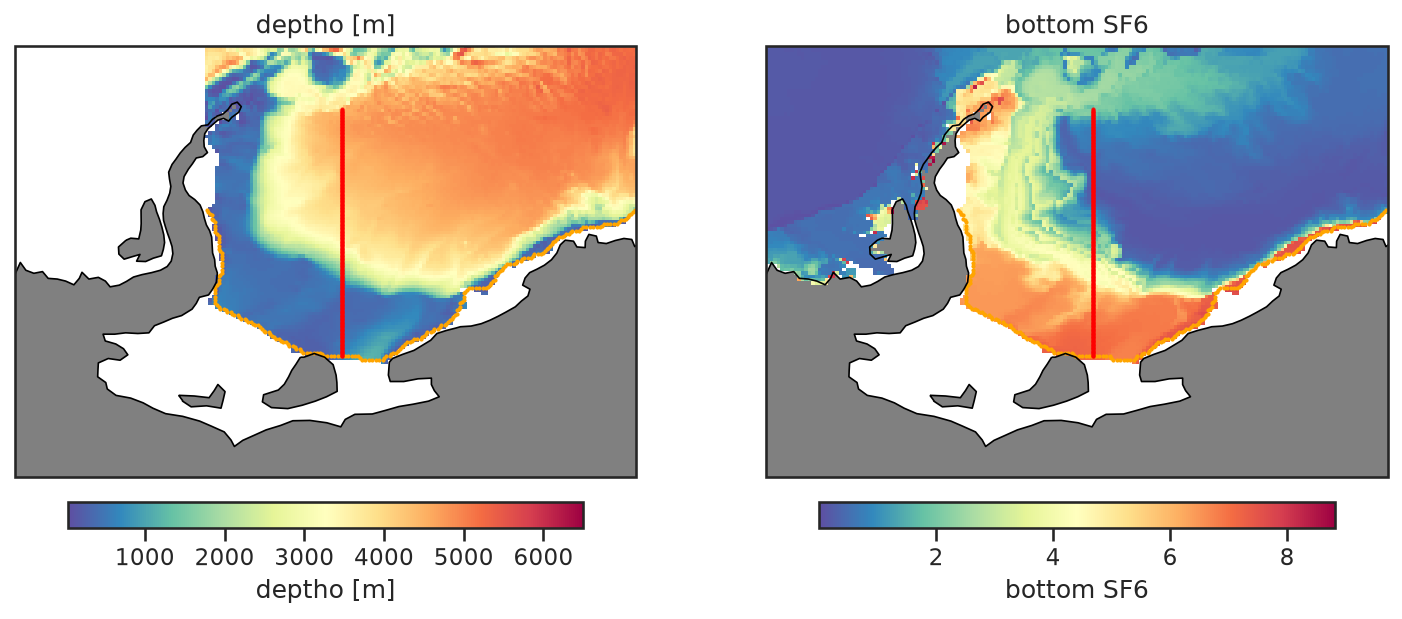

In [18]:
import cartopy.crs as ccrs
import cartopy

fig, axs = plt.subplots(
    1, 2, figsize=(10, 4),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True,
)

vars = [
    (ds_weddell["deptho"], "deptho [m]"),
    (bottom_sf6.sel(expt="control").sel(year=2050, method="nearest"), "bottom SF6"),
]

indices = np.arange(46, geometry.sizes["section"]-32)
transects_subset = transects.isel(section=indices)

for ax, (var, label) in zip(axs, vars):
    ax.set_extent([-90, 0, -85, -60], crs=ccrs.PlateCarree())
    ax.coastlines(resolution="110m", linewidth=0.8)
    ax.add_feature(cartopy.feature.LAND.with_scale("110m"), facecolor="grey")
    ax.set_aspect(2.5)
    ax.set_title(label)

    m = ax.pcolormesh(var["lon"], var["lat"], var, transform=ccrs.PlateCarree(),
                      shading="auto", cmap="Spectral_r")
    fig.colorbar(m, ax=ax, shrink=0.7, orientation="horizontal", label=label)

    ax.scatter(geometry["contour_lon"], geometry["contour_lat"],
               transform=ccrs.PlateCarree(), s=1, color="orange")

    for i in range(transects_subset.sizes["section"]):
        ax.scatter(transects_subset["lon"].isel(section=i),
                   transects_subset["lat"].isel(section=i),
                   transform=ccrs.PlateCarree(), s=1, color="red", alpha=0.8)

In [19]:
avg_transects = transects_subset.mean("section").compute()
time_mean_transects = avg_transects.sel(year = slice(2050, 2100)).mean("year", skipna = True).compute() 

/user/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/numbagg/decorators.py:245: RuntimeWarning: invalid value encountered in nanmean
  return self.gufunc(target=self.target)(*arrays, axis=-1)
/user/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/numbagg/decorators.py:245: RuntimeWarning: invalid value encountered in nanmean
  return self.gufunc(target=self.target)(*arrays, axis=-1)
/user/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/numbagg/decorators.py:245: RuntimeWarning: invalid value encountered in nanmean
  return self.gufunc(target=self.target)(*arrays, axis=-1)
/user/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/numbagg/decorators.py:245: RuntimeWarning: invalid value encountered in nanmean
  return self.gufunc(target=self.target)(*arrays, axis=-1)


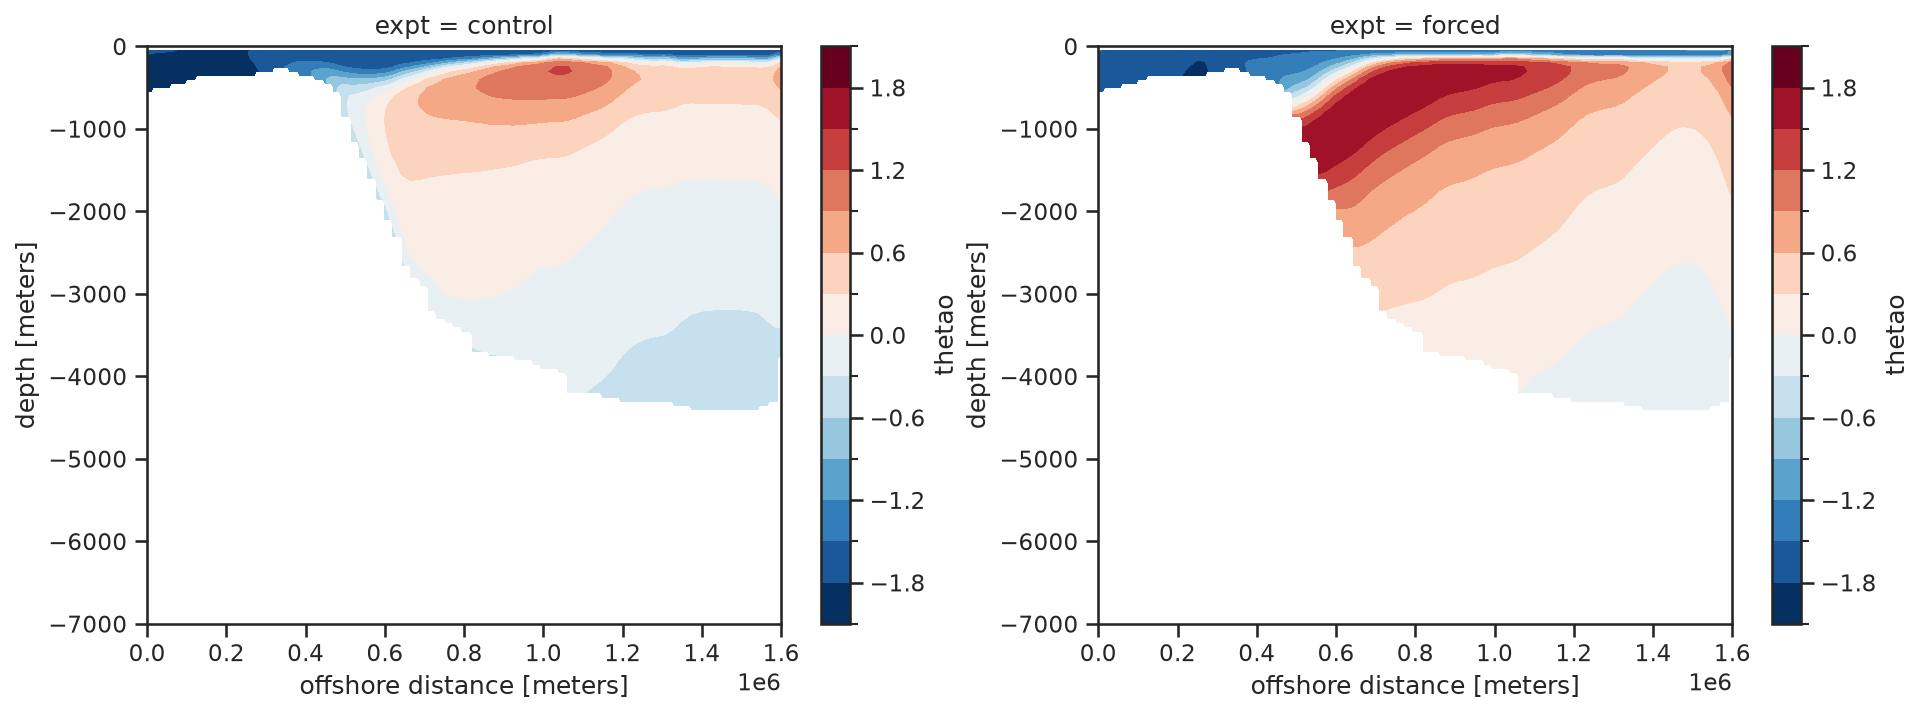

In [20]:
fig, ax = plt.subplots(1,2, figsize = (15, 5))
time_mean_var = time_mean_transects.thetao
time_mean_var.sel(expt = "control").plot.contourf(ax = ax[0], yincrease = True, levels= 15)
time_mean_var.sel(expt = "forced").plot.contourf(ax = ax[1],yincrease = True, levels= 15)

for a in ax: 
    a.set_ylabel("depth [meters]")
    a.set_xlabel("offshore distance [meters]")

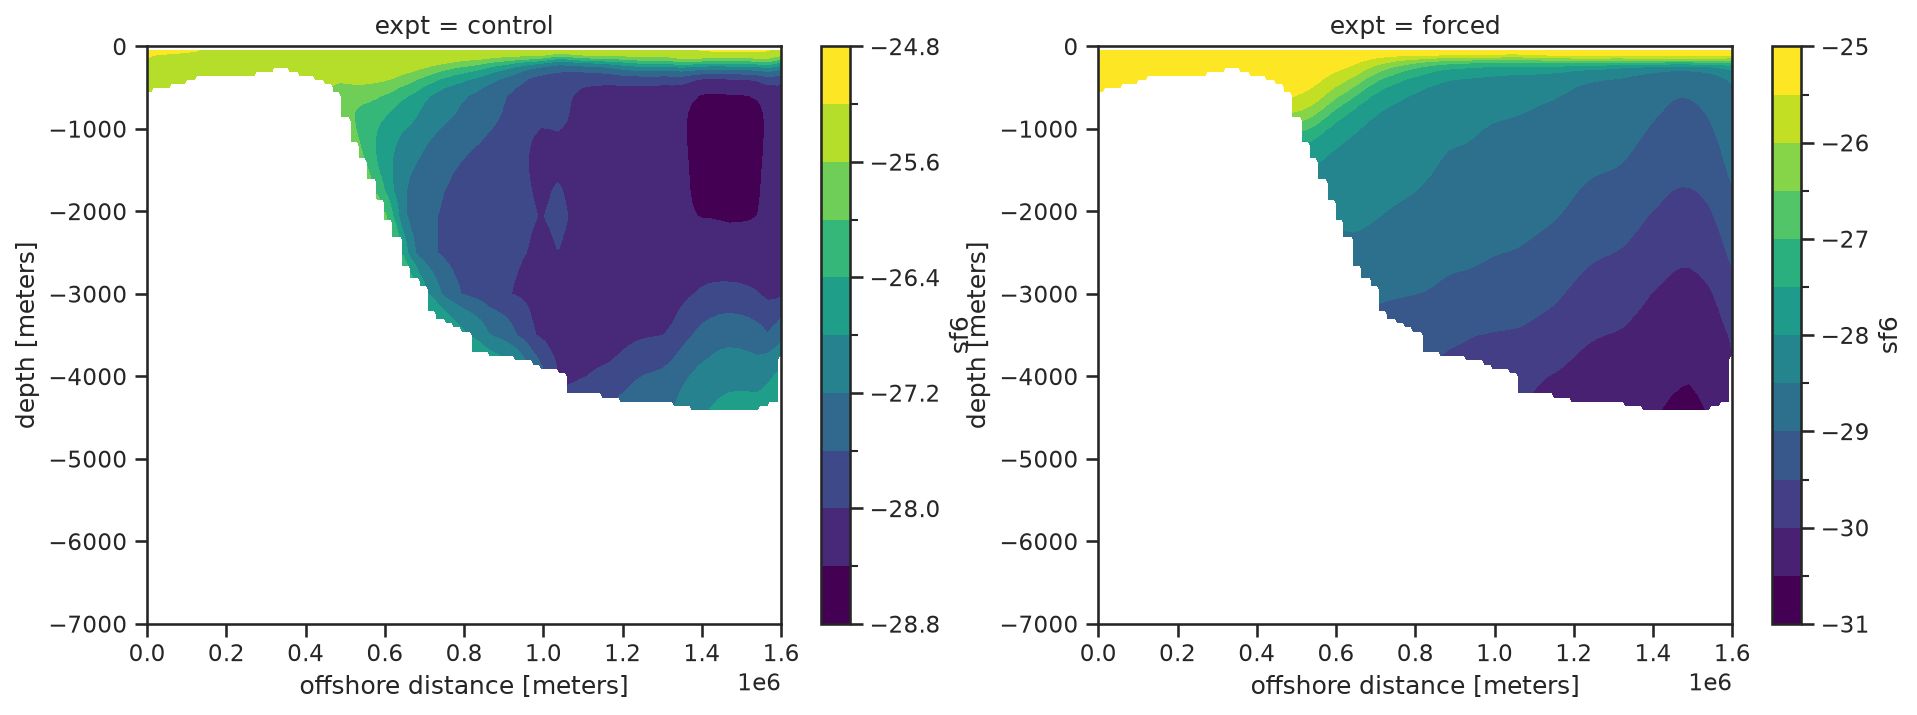

In [21]:
fig, ax = plt.subplots(1,2, figsize = (15, 5))
time_mean_var = np.log(time_mean_transects.sf6)
time_mean_var.sel(expt = "control").plot.contourf(ax = ax[0], yincrease = True, levels= 12)
time_mean_var.sel(expt = "forced").plot.contourf(ax = ax[1],yincrease = True, levels= 12)

for a in ax: 
    a.set_ylabel("depth [meters]")
    a.set_xlabel("offshore distance [meters]")

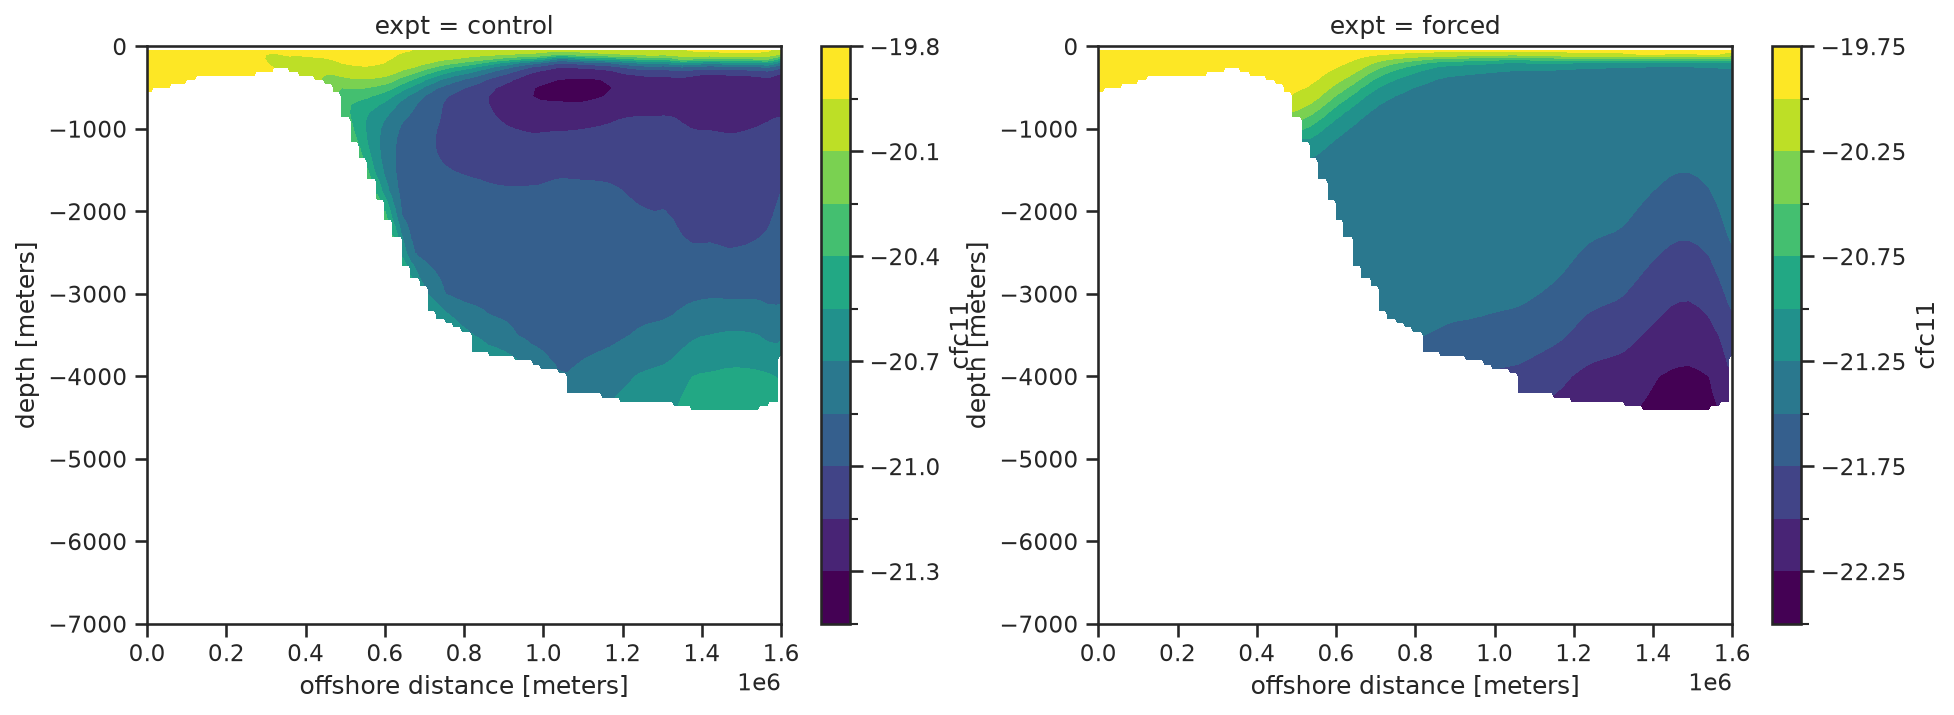

In [22]:
fig, ax = plt.subplots(1,2, figsize = (15, 5))
time_mean_var = np.log(time_mean_transects.cfc11)
time_mean_var.sel(expt = "control").plot.contourf(ax = ax[0], yincrease = True, levels= 12)
time_mean_var.sel(expt = "forced").plot.contourf(ax = ax[1],yincrease = True, levels= 12)

for a in ax: 
    a.set_ylabel("depth [meters]")
    a.set_xlabel("offshore distance [meters]")


In [36]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import FixedLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import cmocean.cm as cmo
import cmocean
import matplotlib.patheffects as pe


LAND = cfeature.NaturalEarthFeature(
    "physical",
    "land",
    "110m",
    facecolor="lightgrey",
)


def contour_label_positions(ax, CS, window=(0.08, 0.10, 0.92, 0.90)):
    x0, y0, x1, y1 = window
    positions = []

    for path in CS.get_paths():
        verts = path.vertices
        if verts is None or len(verts) < 2:
            continue

        verts_axes = ax.transAxes.inverted().transform(ax.transData.transform(verts))
        inside = (
            (verts_axes[:, 0] >= x0)
            & (verts_axes[:, 0] <= x1)
            & (verts_axes[:, 1] >= y0)
            & (verts_axes[:, 1] <= y1)
        )

        idx = np.flatnonzero(inside)
        if idx.size:
            positions.append(tuple(verts[idx[idx.size // 2]]))

    return positions


def plot_row(
    fig,
    axs,
    var,
    bg,
    transects_subset,
    levels,
    cmap,
    norm,
    avg_yrs,
    units,
    section_titles,
    timeseries_titles,
    z=slice(None),
    scale=1.0,
    log=False,
    contour_fmt="%g",
    surf_loc=(380, -430),
    bot_loc=(680, -3000),
    data_crs=None,
    map_extent=(-89, 10, -85, -61),
    background_cmap="RdPu",
    background_label="bottom SF$_6$",
    background_vmin=None,
    background_vmax=None,
    background_norm = None,
    plot_contours=True,
    clabel_colors="k",
    clabel_window=(0.10, 0.12, 0.90, 0.88),
    clabel_fontsize=11,
    add_time_label=True,
    add_units=False,
    cbar_units=None,
    hide_section_xlabel=False,
    draw_gridlines=True,
    xticks=None,
    yticks=None,
    panel_label=None,
):
    if data_crs is None:
        data_crs = ccrs.PlateCarree()

    if cbar_units is None:
        cbar_units = units

    ax_map = axs["map"]
    ax_section_control = axs["section_control"]
    ax_section_forced = axs["section_forced"]
    ax_shelf = axs["shelf"]
    ax_slope = axs["slope"]

    ax_map.set_extent(map_extent, crs=data_crs)

    m = ax_map.pcolormesh(
        bg.lon,
        bg.lat,
        bg,
        transform=data_crs,
        shading="auto",
        cmap=background_cmap,
        vmin=background_vmin,
        vmax=background_vmax,
        norm = background_norm
    )
    ax_map.coastlines(resolution="110m", linewidth=0.5)
    ax_map.add_feature(LAND, zorder=1)
    for i in range(transects_subset.sizes["section"]):
        ax_map.scatter(
            transects_subset.lon.isel(section=i),
            transects_subset.lat.isel(section=i),
            transform=data_crs,
            s=1,
            color="limegreen",
            alpha=0.5,
            label="sampled sections" if i == 0 else None,
        )

    ax_map.legend(loc="upper left")

    if draw_gridlines:
        if xticks is None:
            xticks = np.arange(-180, 181, 10)
        if yticks is None:
            yticks = np.arange(-80, -49, 5)

        gl = ax_map.gridlines(
            crs=data_crs,
            draw_labels=True,
            linewidth=0.7,
            alpha=0.5,
        )
        gl.xlocator = FixedLocator(xticks)
        gl.ylocator = FixedLocator(yticks)
        gl.x_inline = False
        gl.y_inline = False
        gl.xpadding = 6
        gl.ypadding = 6
        gl.rotate_labels = False
        gl.top_labels = False
        gl.right_labels = False

    cax = inset_axes(
        ax_map,
        width="92%",
        height="4%",
        loc="lower center",
        bbox_to_anchor=(0.0, -0.2, 1.0, 1.0),
        bbox_transform=ax_map.transAxes,
        borderpad=0.0,
    )
    fig.colorbar(m, cax=cax, orientation="horizontal").set_label(background_label)

    if panel_label is not None:
        ax_map.text(
            0.98,
            0.02,
            panel_label,
            transform=ax_map.transAxes,
            ha="right",
            va="bottom",
            fontsize=30,
            fontweight="bold",
            color="k",
            zorder=30,
        )

    var = var.sel(z_l=z) * scale
    v = var.sel(year=avg_yrs)

    year_label = f"{int(v.year.min())}-{int(v.year.max())}"
    v = v.mean("year")

    if log:
        v = np.log(v)

    for ax, expt, title in zip(
        [ax_section_control, ax_section_forced],
        ["control", "forced"],
        section_titles,
    ):
        ax.contourf(
            v.transect_length,
            np.abs(v.z_l),
            v.sel(expt=expt),
            levels=levels,
            cmap=cmap,
            norm=norm,
            extend="both",
        )

        if plot_contours:
            CS = ax.contour(
                v.transect_length,
                np.abs(v.z_l),
                v.sel(expt=expt),
                levels=levels,
                colors=clabel_colors,
                linewidths=0.8,
            )

            pos = contour_label_positions(ax, CS, window=clabel_window)
            ax.clabel(
                CS,
                CS.levels,
                manual=pos if pos else None,
                fontsize=clabel_fontsize,
                fmt=contour_fmt,
            )

        ax.plot(
            surf_loc[0],
            np.abs(surf_loc[1]),
            marker="*",
            ms=20,
            mfc="yellow",
            mec="k",
            mew=0.8,
            zorder=10,
            alpha=0.8,
        )
        ax.text(
            surf_loc[0] - 180,
            np.abs(surf_loc[1] - 600),
            "shelf",
            ha="left",
            va="center",
            color="yellow",
            fontweight="bold",
            zorder=11,
            path_effects=[
                pe.Stroke(linewidth=1.0, foreground="black"),
                pe.Normal(),
            ],
        )

        ax.plot(
            bot_loc[0],
            np.abs(bot_loc[1]),
            marker="o",
            ms=16,
            mfc="yellow",
            mec="k",
            mew=0.8,
            zorder=10,
            alpha=0.8,
        )
        ax.text(
            bot_loc[0] - 260,
            np.abs(bot_loc[1] - 100),
            "slope",
            ha="left",
            va="center",
            color="yellow",
            fontweight="bold",
            zorder=11,
            path_effects=[
                pe.Stroke(linewidth=1.0, foreground="black"),
                pe.Normal(),
            ],
        )

        if add_time_label:
            ax.text(
                0.02,
                0.05,
                year_label,
                transform=ax.transAxes,
                ha="left",
                va="bottom",
                fontsize=14,
                color="w",
                bbox=dict(
                    boxstyle="round,pad=0.2",
                    fc="k",
                    ec="none",
                    alpha=0.45,
                ),
                zorder=20,
            )

        if add_units:
            inline_label = cbar_units if log else units
            ax.text(
                0.02,
                0.14,
                f"Units: {inline_label}",
                transform=ax.transAxes,
                ha="left",
                va="bottom",
                fontsize=10,
                color="w",
                bbox=dict(
                    boxstyle="round,pad=0.2",
                    fc="k",
                    ec="none",
                    alpha=0.45,
                ),
                zorder=20,
            )

        ax.invert_yaxis()
        ax.set_facecolor("grey")
        ax.set_ylabel("Depth [m]")
        ax.set_title(title, loc="left", fontweight="bold")

    if hide_section_xlabel:
        ax_section_control.set_xlabel("")
        ax_section_forced.set_xlabel("")
        ax_section_control.tick_params(labelbottom=False)
        ax_section_forced.tick_params(labelbottom=False)
    else:
        ax_section_control.set_xlabel("")
        ax_section_forced.set_xlabel("Offshore Distance [km]")
        ax_section_control.tick_params(labelbottom=False)

    ts = var.interp(
        transect_length=surf_loc[0],
        z_l=surf_loc[1],
        method="nearest",
        kwargs={"fill_value": np.nan},
    )
    tb = var.interp(
        transect_length=bot_loc[0],
        z_l=bot_loc[1],
        method="nearest",
        kwargs={"fill_value": np.nan},
    )

    colors = {"control": "k", "forced": "r"}
    labels = {
        "control": "piControl",
        "forced": "Historical/SSP5-8.5",
    }

    for expt, color in colors.items():
        ax_shelf.plot(ts.year, ts.sel(expt=expt), c=color, label=labels[expt])
        ax_slope.plot(tb.year, tb.sel(expt=expt), c=color, label=labels[expt])

    ax_shelf.tick_params(labelbottom=False)
    ax_shelf.set_title(timeseries_titles[0], loc="left", fontweight="bold")
    ax_slope.set_title(timeseries_titles[1], loc="left", fontweight="bold")

    for ax in [ax_shelf, ax_slope]:
        ax.set_ylabel(f"[{units}]")
        ax.grid(alpha=0.3)
        ax.legend(frameon=False)

    return {
        **axs,
        "ts": ts,
        "tb": tb,
    }

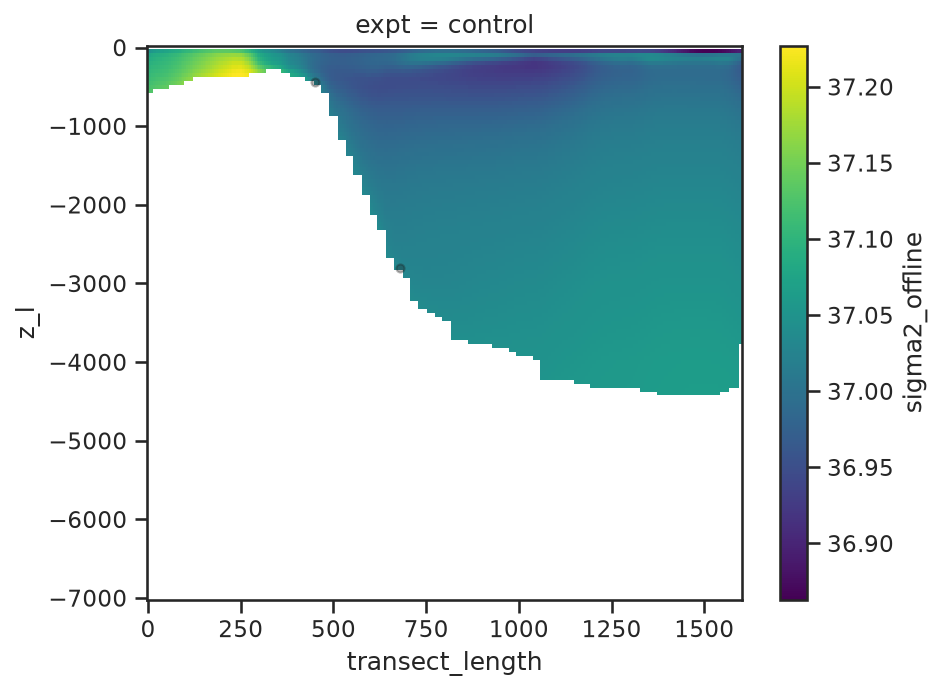

In [37]:
surf_loc = (450, -440)
bot_loc = (680, -2800)
lat_s, z_s = surf_loc
lat_b, z_b = bot_loc

avg_trans = avg_transects.interp(
    year=np.arange(1850, 2101),
    method="linear",
    kwargs={"fill_value": "extrapolate"},
)
avg_trans["transect_length"] = 1e-3 * avg_transects.transect_length

fig, ax = plt.subplots()
avg_trans.sigma2_offline.mean("year").sel(expt = "control").plot(ax = ax, zorder = 0)

ax.scatter(lat_s, z_s, c = "k", s = 15, zorder = 100, alpha = 0.3)
ax.scatter(lat_b, z_b, c = "k", s = 15, zorder = 100, alpha = 0.3)


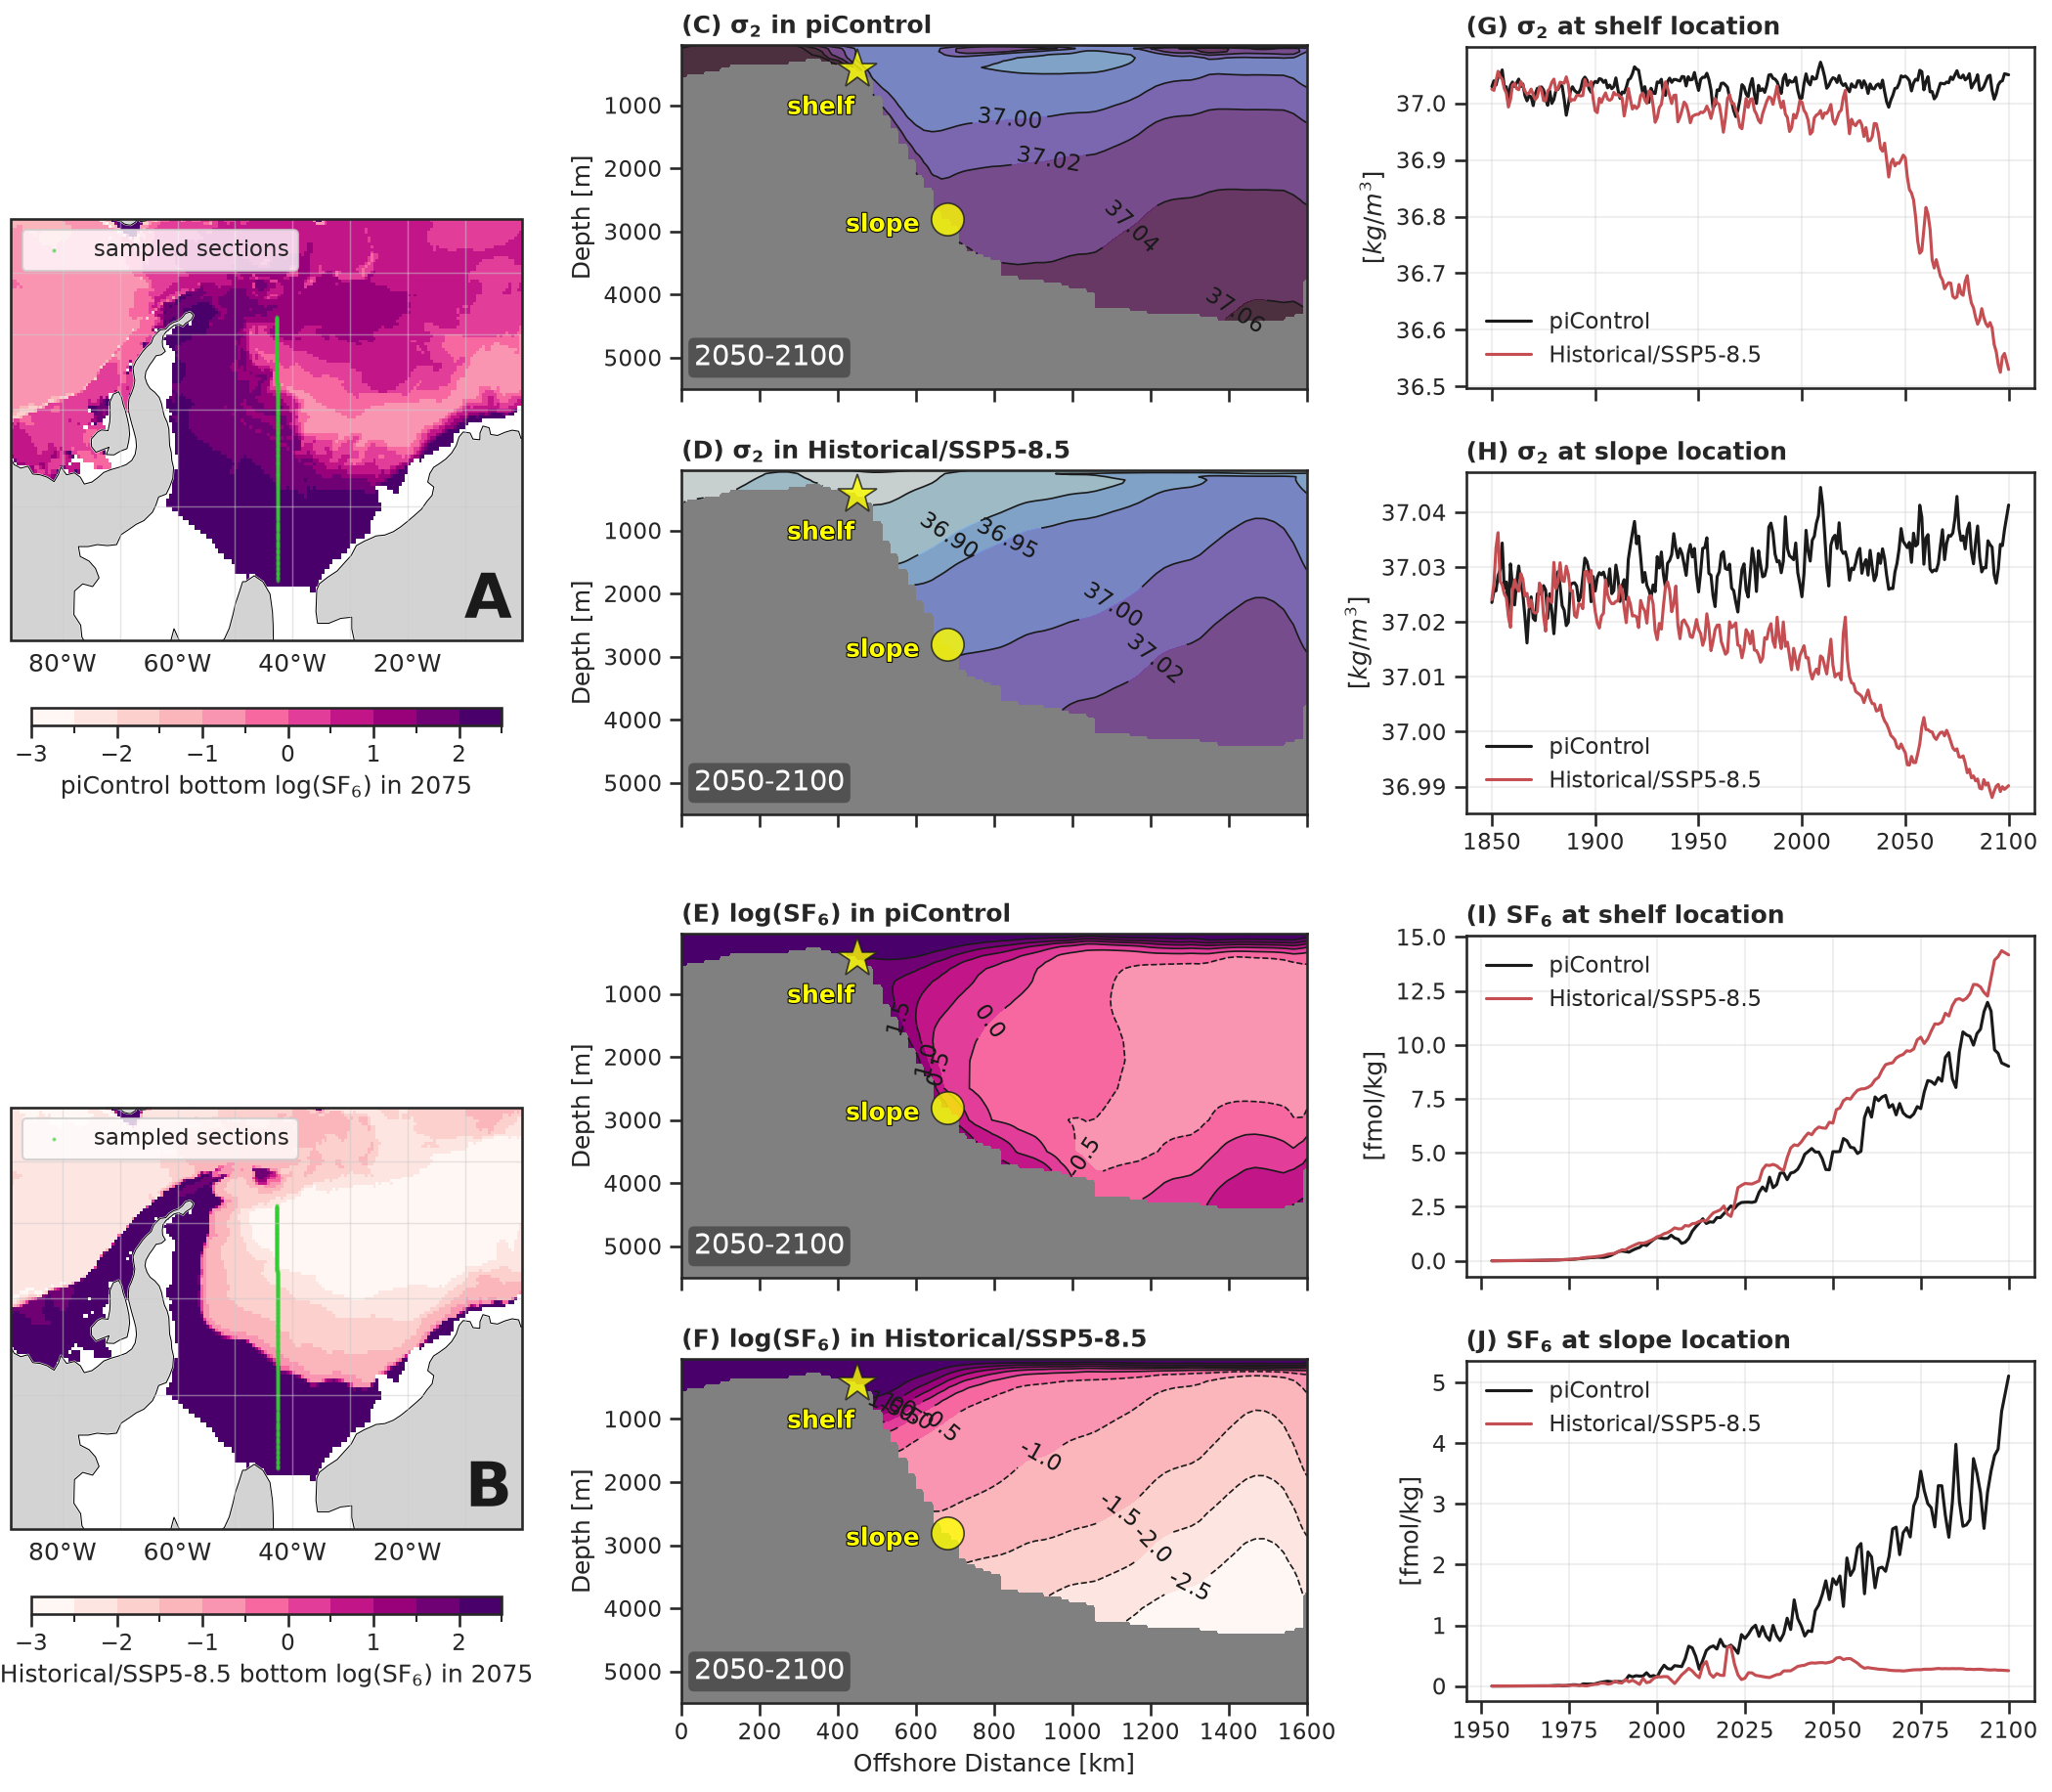

In [38]:
map_extent = (-89, 0, -80, -55)
z_slice=slice(-5500, -10)

map_proj = ccrs.Mercator(
    min_latitude=map_extent[-2],
    max_latitude=map_extent[-1],
    latitude_true_scale=-70,
)

data_crs = ccrs.PlateCarree()


fig = plt.figure(figsize=(15, 13), constrained_layout=False)

gs = fig.add_gridspec(
    2,
    3,
    width_ratios=(0.9, 1.1, 1.0),
    height_ratios=(1.0, 1.0),
    wspace=0.28,
    hspace=0.05,
)

fig.subplots_adjust(
    left=0.06,
    right=0.98,
    bottom=0.06,
    top=0.97,
)

axs = {}

for row in range(2):
    gs_section = gs[row, 1].subgridspec(2, 1, hspace=0.01)
    gs_timeseries = gs[row, 2].subgridspec(2, 1, hspace=0.01)

    axs[row] = {}

    axs[row]["map"] = fig.add_subplot(gs[row, 0], projection=map_proj)

    axs[row]["section_control"] = fig.add_subplot(gs_section[0, 0])
    axs[row]["section_forced"] = fig.add_subplot(
        gs_section[1, 0],
        sharex=axs[row]["section_control"],
    )

    axs[row]["shelf"] = fig.add_subplot(gs_timeseries[0, 0])
    axs[row]["slope"] = fig.add_subplot(
        gs_timeseries[1, 0],
        sharex=axs[row]["shelf"],
    )

for row in range(2):
    for key in ["section_control", "section_forced"]:
        axs[row][key].set_box_aspect(0.55)

    for key in ["shelf", "slope"]:
        axs[row][key].set_box_aspect(0.6)

levels_sigma = [
    36.50, 36.70, 36.90, 36.95,
    37.00, 37.02, 37.04,
    37.06, 37.08,
]
cmap_sigma = plt.get_cmap(cmocean.tools.lighten(cmo.dense, 0.7), len(levels_sigma) - 1)
norm_sigma = BoundaryNorm(levels_sigma, ncolors=cmap_sigma.N, clip=True)

levels_sf6 = np.arange(-3.0, 2.5 + 0.01, 0.5)
cmap_sf6 = plt.get_cmap("RdPu", len(levels_sf6) - 1)
norm_sf6 = BoundaryNorm(levels_sf6, ncolors=cmap_sf6.N, clip=True)

log_bottom_sf6 = np.log(bottom_sf6)
axs1 = plot_row(
    fig=fig,
    axs=axs[0],
    var=avg_trans.sigma2_offline,
    bg=log_bottom_sf6.sel(year=2075, expt="control"),
    transects_subset=transects_subset,
    levels=levels_sigma,
    cmap=cmap_sigma,
    norm=norm_sigma,
    avg_yrs=slice(2050, 2100),
    units=r"$kg/m^3$",
    section_titles=[
        r"(C) $\mathbf{\sigma_2}$ in piControl",
        r"(D) $\mathbf{\sigma_2}$ in Historical/SSP5-8.5",
    ],
    timeseries_titles=[
        r"(G) $\mathbf{\sigma_2}$ at shelf location",
        r"(H) $\mathbf{\sigma_2}$ at slope location",
    ],
    z=z_slice,
    contour_fmt="%.2f",
    surf_loc=surf_loc,
    bot_loc=bot_loc,
    data_crs=data_crs,
    background_cmap=cmap_sf6,
    background_norm = norm_sf6,
    background_label="piControl bottom log(SF$_6$) in 2075",
    hide_section_xlabel=True,
    panel_label="A",
    map_extent=map_extent,
)



axs2 = plot_row(
    fig=fig,
    axs=axs[1],
    var=avg_trans.sf6,
    bg=log_bottom_sf6.sel(year=2075, expt="forced"),
    transects_subset=transects_subset,
    levels=levels_sf6,
    cmap=cmap_sf6,
    norm=norm_sf6,
    avg_yrs=slice(2050, None),
    units="fmol/kg",
    cbar_units=r"$log(fmol/kg)$",
    section_titles=[
        r"(E) log(SF$\mathbf{_6}$) in piControl",
        r"(F) log(SF$\mathbf{_6}$) in Historical/SSP5-8.5",
    ],
    timeseries_titles=[
        r"(I) SF$\mathbf{_6}$ at shelf location",
        r"(J) SF$\mathbf{_6}$ at slope location",
    ],
    z=z_slice,
    scale=1e12 / 1035 * 1e3,
    log=True,
    contour_fmt="%.1f",
    surf_loc=surf_loc,
    bot_loc=bot_loc,
    data_crs=data_crs,
    background_cmap=cmap_sf6,
    background_norm = norm_sf6,
    background_label="Historical/SSP5-8.5 bottom log(SF$_6$) in 2075",
    hide_section_xlabel=False,
    map_extent=map_extent,
    panel_label="B",
)

fig.savefig("plots/6.Weddell_density_and_sf6.png", dpi=350, bbox_inches="tight")

In [26]:
def calc_p_from_z(z, lat):
    """Calculates pressure from depth z (must be negative downwards) and latitude."""
    return xr.apply_ufunc(
        gsw.p_from_z,
        z, lat,
        dask='parallelized',
        output_dtypes=[float]
    )
def calc_sigma2(SA, CT):
    """Calculates sigma2 using apply_ufunc for safe Dask/Xarray handling."""
    return xr.apply_ufunc(
        gsw.sigma2,
        SA, CT,
        dask='parallelized',
        output_dtypes=[float]
    )

def calc_rho_alpha_beta(SA, CT, p):
    """
    Calculates rho, alpha, and beta using apply_ufunc.
    gsw.rho_alpha_beta returns 3 variables, requiring output_core_dims.
    """
    return xr.apply_ufunc(
        gsw.rho_alpha_beta,
        SA, CT, p,
        dask='parallelized',
        output_core_dims=[[], [], []],
        output_dtypes=[float, float, float]
    )
    

In [27]:
ds_maximum_sbf = xr.open_dataset(outputdir("Southern_Ocean_DSW_1000m_max_SWMT.zarr"))
max_sbf_loc = ds_maximum_sbf["max_surface_boundary_flux_density"]

toTg = 1e-9 
mass_flux_units = "Tg/s"
mass_flux_units_conversion = toTg #kg to Tg 

ds_sfc = xr.open_mfdataset(outputdir(f"Southern_Ocean_DSW_1000m_WMT_Surface_Fluxes_sigma_slice.zarr"))
ds_sfc_SWMT = get_SWMT(ds_sfc)
Wedell_DSW_SWMT = ds_sfc_SWMT.isel(xh = slice(157, 190)).sum(["xh", "yh"])
Wedell_DSW_SWMT["SWMT_residual"] = Wedell_DSW_SWMT["SWMT_salt_residual"] + Wedell_DSW_SWMT["SWMT_heat_residual"] 

In [28]:
abyssal_sbf = Wedell_DSW_SWMT["SWMT"].fillna(0.0)

max_locations = abyssal_sbf.argmax("sigma2_l_target")

control_max = abyssal_sbf["sigma2_l_target"][max_locations.sel(exp = "control")].rename("max_surface_boundary_flux_density")
forced_max = abyssal_sbf["sigma2_l_target"][max_locations.sel(exp = "forced")].rename("max_surface_boundary_flux_density")

max_sbf_weddell_loc = xr.concat([control_max, forced_max], dim = "exp").compute()
max_sbf_weddell = toTg * select_from_location(Wedell_DSW_SWMT, max_sbf_weddell_loc).compute()

/user/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/distributed/client.py:3415: UserWarning: Sending large graph of size 11.19 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [29]:
avg_transects_copy = 1.0 * avg_trans

avg_transects_copy['sigma2_obs'] = calc_sigma2(
    avg_transects_copy.so.astype("float64"),
    avg_transects_copy.thetao.astype("float64"))

window = 2100
# select locations
ts = avg_transects_copy.interp(transect_length=lat_s, z_l=z_s, method="nearest",
    kwargs={"fill_value": np.nan},).sel(year = slice(None, window))
tb = avg_transects_copy.interp(transect_length=lat_b, z_l=z_b, method="nearest",
    kwargs={"fill_value": np.nan},).sel(year = slice(None, window))

time = ts.year
# Point 1 (Upper)
SA_1 = ts["so"].astype("float64")
CT_1 = ts["thetao"]
PT_1 = ts['sigma2_offline']
# Point 2 (Lower)
SA_2 = tb["so"]
CT_2 =  tb["thetao"]
PT_2 = tb['sigma2_offline']

# Actual Sigma-2 Difference
#sigma2_obs is biased high compared to sigma2_offline (i.e., sigma2_obs is lighter than sigma2_offline
#but the differences (PT_2 - PT_1) are approximately the same.
density_difference_ds = (-(PT_2 - PT_1)).to_dataset(name = "actual_sigma2_diff") 

# Linear Reconstruction Components
delta_CT =  -(CT_2 - CT_1)
delta_SA = -(SA_2 - SA_1)

mid_CT = (CT_2 + CT_1) / 2
mid_SA = (SA_2 + SA_1) / 2
p_ref = 2000.0 # sigma2 reference pressure

rho_mid, alpha_mid, beta_mid = calc_rho_alpha_beta(mid_SA, mid_CT, p_ref)

density_difference_ds["T_contribution"] = (-rho_mid * alpha_mid * delta_CT)
density_difference_ds["S_contribution"] = rho_mid * beta_mid * delta_SA
density_difference_ds["reconstructed_sigma2_diff"] = density_difference_ds["T_contribution"] + density_difference_ds["S_contribution"]

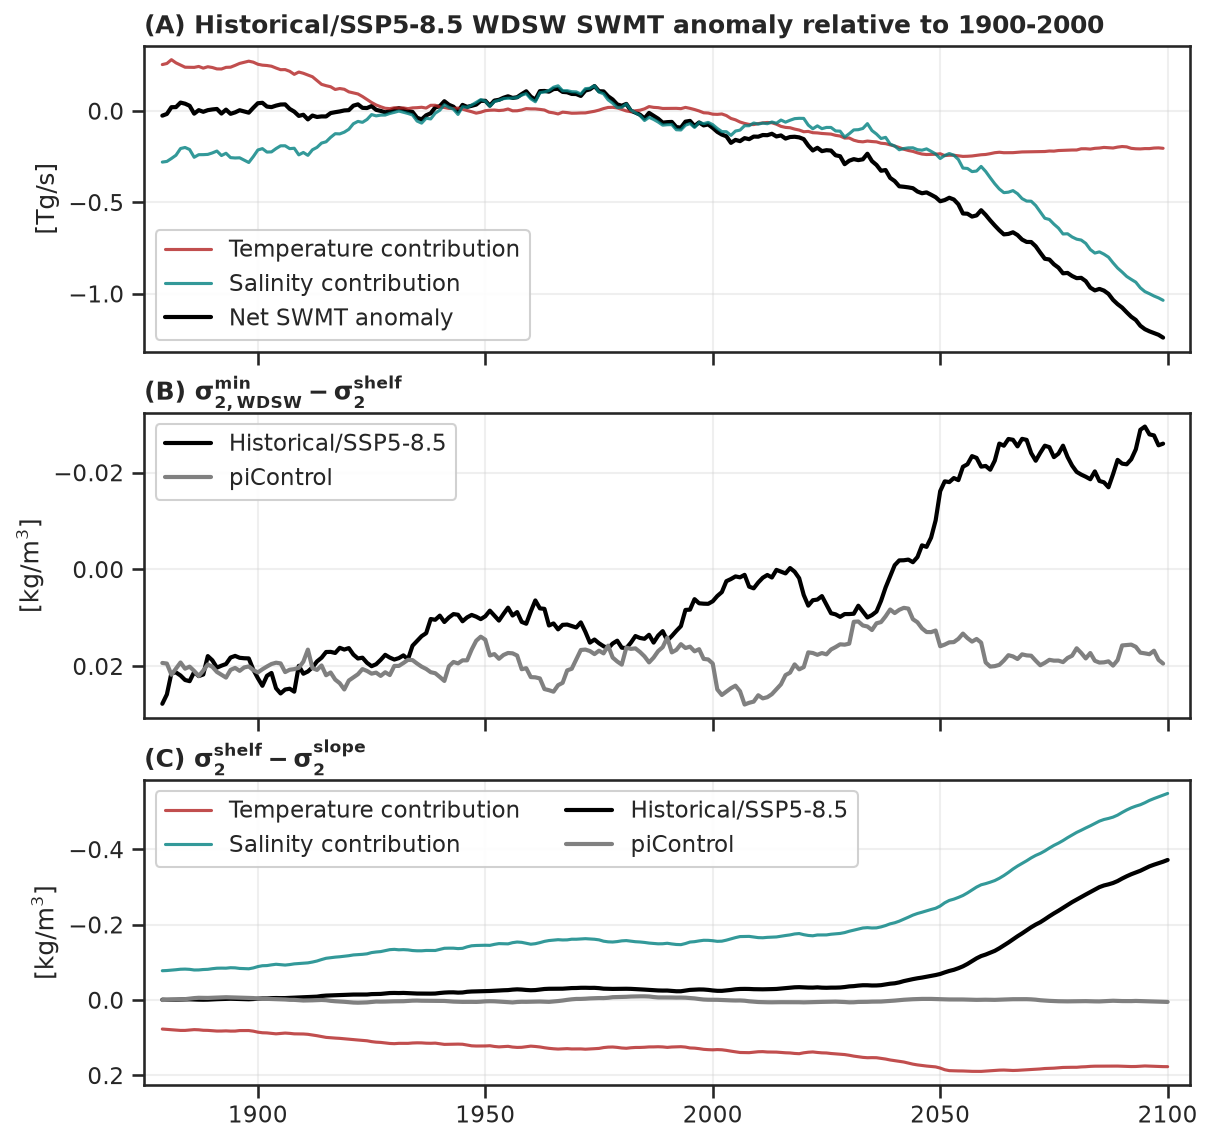

In [30]:
rolling_window = 30
center = False
# ==========================================
# 4. SINGLE AXIS VISUALIZATION
# ==========================================
fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex = True)

ax = axes[0]

forced_SWMT = max_sbf_weddell.sel(exp = "forced")
forced_SWMT = forced_SWMT - max_sbf_weddell.sel(exp = "forced").sel(year = slice(1900, 2000)).mean("year")
    
forced_SWMT = forced_SWMT.rolling(year = rolling_window, center = center).mean("year")
SWMT_times = forced_SWMT.year
ax.plot(SWMT_times, forced_SWMT["SWMT_heat"], label='Temperature contribution', color='firebrick', alpha=0.8, linewidth=1.5, zorder = 10)
ax.plot(SWMT_times, forced_SWMT["SWMT_salt"], label='Salinity contribution', color='teal', alpha=0.8, linewidth=1.5, zorder = 10)
ax.plot(SWMT_times, forced_SWMT["SWMT"], label = "Net SWMT anomaly", color='black', linewidth=2)

# forced_SWMT["SWMT_residual"].plot(ax = ax)
ax.legend(loc='best', framealpha=0.9)
ax.grid(alpha=0.3)
ax.set_xlabel('')
ax.set_ylabel(r'[Tg/s]')
ax.set_title("(A) Historical/SSP5-8.5 WDSW SWMT anomaly relative to 1900-2000", loc="left", fontweight = "bold")
# ax.set_xlim(-3, None)

ax = axes[2]
# Plot the individual T and S contributions
wedell_density_diff = density_difference_ds.sel(expt = "forced").rolling(year = rolling_window, center = center).mean("year")
ax.plot(time, wedell_density_diff["T_contribution"], label='Temperature contribution', color='firebrick', alpha=0.8, linewidth=1.5, zorder = 10)
ax.plot(time, wedell_density_diff["S_contribution"], label='Salinity contribution', color='teal', alpha=0.8, linewidth=1.5, zorder = 10)

# Plot the total differences (Actual and Reconstructed)
# Make 'Actual' thick and solid, 'Reconstructed' dashed and slightly thinner to lay on top
ax.plot(time, wedell_density_diff["actual_sigma2_diff"], 
        label=r"Historical/SSP5-8.5", color='black', linewidth=2)
wedell_density_diff = density_difference_ds.sel(expt = "control").rolling(year = rolling_window, center = center).mean("year")
ax.plot(time, wedell_density_diff["actual_sigma2_diff"], 
        label=r"piControl", color='grey', linewidth=2)

# ax.plot(time, wedell_density_diff["reconstructed_sigma2_diff"], label='linear reconstruction of $\Delta\sigma_2$', color='grey', linestyle='--', linewidth=2.0)

# Formatting
# ax.set_xlabel('year')
ax.set_xlabel('')
ax.set_ylabel(r'[kg/m$^{3}$]')
# ax.set_title("(C)", loc="left", fontweight = "bold")
ax.set_title("(C) " + r"$\mathbf{\sigma^{\mathbf{shelf}}_2 - \sigma^{\mathbf{slope}}_2}$", loc="left", fontweight = "bold")

ax.legend(loc='best', framealpha=0.9, ncols = 2)
ax.grid(alpha=0.3)
ax.invert_yaxis()
ax = axes[1]

swmt_shelf_density_difference = max_sbf_weddell_loc - ts['sigma2_offline'].rename({"expt":"exp"})
swmt_shelf_density_difference = swmt_shelf_density_difference.rolling(year = rolling_window, center = center).mean("year")

ax.plot(swmt_shelf_density_difference.year, swmt_shelf_density_difference.sel(exp = "forced"), color='black', 
linewidth=2, label= r"Historical/SSP5-8.5")

ax.plot(swmt_shelf_density_difference.year, swmt_shelf_density_difference.sel(exp = "control"), color='grey', 
linewidth=2, label= r"piControl")

ax.legend(loc='best', framealpha=0.9)
ax.grid(alpha=0.3)
ax.set_xlabel('')
ax.set_ylabel(r'[kg/m$^{3}$]')
# ax.set_title("(B) ", loc="left", fontweight = "bold")
ax.set_title("(B) " + r"$\mathbf{\sigma_{2,\substack{\mathbf{WDSW}}}^{\mathbf{min}} - \sigma^{\mathbf{shelf}}_2}$", loc="left", fontweight = "bold")

ax.set_xlim(1875, 2105)
ax.invert_yaxis()
fig.savefig("plots/7.Weddell_density_SWMT_comparison.png", dpi = 350, bbox_inches = "tight")

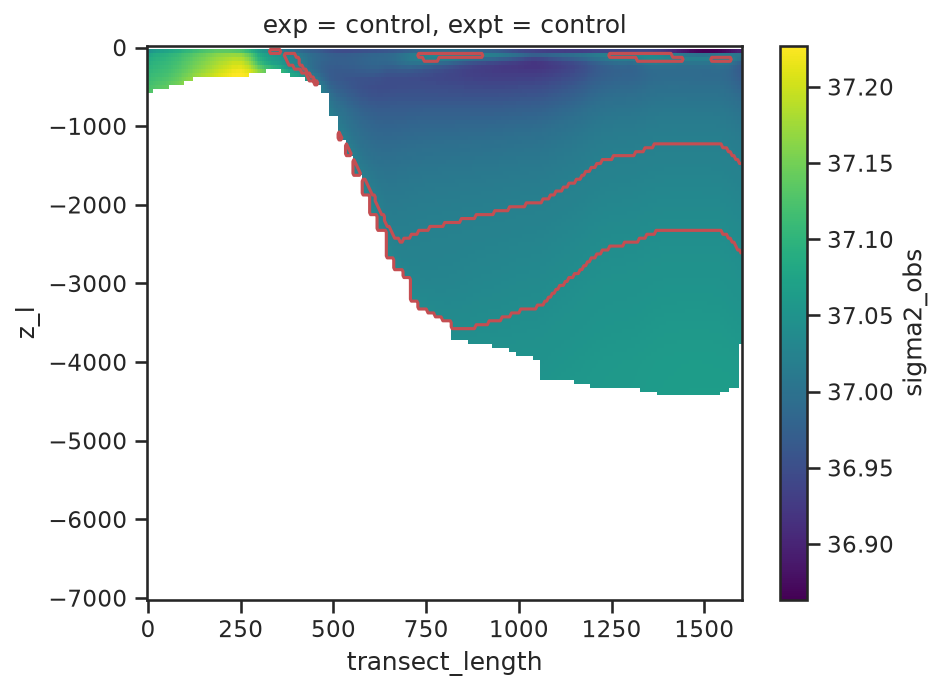

In [31]:
fig, ax = plt.subplots()
avg_transects_copy.sigma2_obs.mean("year").sel(expt = "control").plot(ax = ax)

diff1 =  max_sbf_weddell_loc.sel(exp = "control").mean("year") - avg_transects_copy.sigma2_offline.mean("year").sel(expt = "control")
diff1 = diff1 > 0.0
# diff1.plot.contour(ax = ax)

diff2 =  avg_transects_copy.sigma2_offline.mean("year").sel(expt = "control") - tb['sigma2_offline'].sel(expt = "control").mean("year")
diff2 = np.abs(diff2) < 0.01
(diff1 * diff2).plot.contour(ax = ax, colors = "r")

ax.scatter(z_s, lat_s, c = "k", s = 15, zorder = 100)